This notebook needs Pat Phoompuang's library files

In [59]:
import os, sys
from library.prepare_data import prepare_simulation_data
from library.continuum_grid import compute_continuum_grid
from library.yt_fields import add_flux_fields
from library.visualization import create_projection_plot
from library.calculate_quantities import calculate_filter_width

import numpy as np
import scipy
import copy
from constants import SIMULATION_PATH, SILMARIL_PATH

from initializer import Initializer
from merlinconstants import default_lines as lines, default_wavelengths as wavelengths
from astropy.cosmology import FlatLambdaCDM

from silmaril import Galaxy, Observation, Lens, Detector, open_fits, ang_size, pivot_wavelength
from astropy.coordinates import SkyCoord
from astropy import units as u

from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
import astropy

In [2]:
data_file = SIMULATION_PATH
filter_files = SILMARIL_PATH + "/data/mean_throughputs"
filters = ['F070W', 'F090W', 'F115W', 'F140M', 'F150W', 'F150W', 'F162M', 'F164N', 'F182M', 'F187N', 'F200W', 'F210M', 'F212N', 'F250M', 'F277W', 'F300M', 'F322W2', 'F323N', 'F335M', 'F356W', 'F360M', 'F405N', 'F410M', 'F430M', 'F444W', 'F460M', 'F466N', 'F470N', 'F480M', 'WLP4']
filter = filters[10]
filter_file = os.path.join(filter_files, filter + r"_mean_system_throughput.txt")

In [3]:
ds, ad, ctr, pop2, wl_shifted, trans, width = prepare_simulation_data(
    input_path = data_file,
    filter_path = filter_file
)

yt : [INFO     ] 2026-05-03 23:38:56,585 Parameters: current_time              = 0.3604448649237178 Gyr
yt : [INFO     ] 2026-05-03 23:38:56,586 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2026-05-03 23:38:56,587 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-05-03 23:38:56,588 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2026-05-03 23:38:56,589 Parameters: cosmological_simulation   = True
yt : [INFO     ] 2026-05-03 23:38:56,592 Parameters: current_redshift          = 12.171087046255657
yt : [INFO     ] 2026-05-03 23:38:56,593 Parameters: omega_lambda              = 0.685000002384186
yt : [INFO     ] 2026-05-03 23:38:56,595 Parameters: omega_matter              = 0.314999997615814
yt : [INFO     ] 2026-05-03 23:38:56,597 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2026-05-03 23:38:56,598 Parameters: hubble_constant           = 0.674000015258789
yt : [WARNING  ] 2026-05-03 23:38:57,027 This output

Loading filter data from file: C:/Users/kevin/aether/silmaril/silmaril/data/mean_throughputs\F200W_mean_system_throughput.txt
Filter wavelength range: 1279.6-1748.1 Å


In [4]:
df_results, interp_funcs = compute_continuum_grid(
    min_temp = 1e3, max_temp = 1e5, num_temp_grid = 15,
    min_dense = 1e-4, max_dense = 1e6, num_dense_grid = 15,
    min_wl = 912, max_wl = 1e5, num_wl_grid = 10000,
    filter_wl = wl_shifted,     # 1D array from prepare_simulation_data
    filter_output = trans,      # 1D array from prepare_simulation_data
    save_dir = "continuum_single"
)

Processing single filter...
Saving dataframe to: continuum_single
Filter range: 1281.1-1746.6 Å
Points with transmission > 0: 614


c:\Users\kevin\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyneb\core\continuum.py:135: RuntimeWarning: invalid value encountered in power
  A = 202.0 * (y * (1. - y) * (1. -(4. * y * (1 - y))**0.8) + 0.88 * ( y * (1 - y))**1.53 * (4. * y * (1 - y))**0.8)


Saved: df_wl1281-1747A.txt (225 rows)
Creating variable df01 for single filter:
  Created df01 = shape (225, 5)


In [5]:
# add flux fields to yt dataset
ds, filter_list = add_flux_fields(
    ds = ds, 
    interp_funcs = interp_funcs, 
    min_temp = 1e3, 
    max_temp = 1e5, 
    min_dense = 1e-4, 
    max_dense = 1e6,
    he_h_ratio = 0.1
)

Processing single filter...
Added: flux_contH
Added: flux_cont2p
Added: flux_contff
Added: flux_total

Successfully added fields for single filter


In [6]:
merlin = Initializer(ds)
merlin._load_fields()
ds = merlin.ds
merlin._load_luminosity_flux()
ad = ds.all_data()

yt : [WARNING  ] 2026-05-03 23:40:12,994 Field ('ramses', 'Pressure') already exists. To override use `force_override=True`.
yt : [WARNING  ] 2026-05-03 23:40:12,998 Field ('ramses', 'xHI') already exists. To override use `force_override=True`.
yt : [WARNING  ] 2026-05-03 23:40:13,001 Field ('ramses', 'xHII') already exists. To override use `force_override=True`.
yt : [WARNING  ] 2026-05-03 23:40:13,005 Field ('ramses', 'xHeII') already exists. To override use `force_override=True`.
yt : [WARNING  ] 2026-05-03 23:40:13,010 Field ('ramses', 'xHeIII') already exists. To override use `force_override=True`.


c:\Users\kevin\AppData\Local\Programs\Python\Python311\Lib\site-packages\merlin_spectra\linelists\linelist-all.dat
c:\Users\kevin\AppData\Local\Programs\Python\Python311\Lib\site-packages\merlin_spectra\linelists\linelist-all.dat


c:\Users\kevin\AppData\Local\Programs\Python\Python311\Lib\site-packages\merlin_spectra\emission.py:96: UserWarning: Input line 6 contained no data and will not be counted towards `max_rows=1`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  np.loadtxt(linelist_path, unpack=True, dtype=float, max_rows=1,


minU=-9.0, maxU=2.0, stepU=0.5, minN=-4.0, maxN=7.0, stepN=0.5, minT=1.0, maxT=8.0, stepT=0.2
Line List Shape = (26, 19044)
23 23 36


In [7]:
def get_filter_interpolator(
    filter_file: str,
    z: float = 0.0,
):
    """
    Returns a CubicSpline interpolator for a given JWST filter
    based on the starburst spectrum table.

    Parameters
    ----------
    filter_file : str
        Absolute or relative path to filter throughput file
    z : float
        Redshift of the galaxy (default 0)

    Returns
    -------
    interpolator : scipy.interpolate.CubicSpline
        Function of stellar age [Myr] giving mean photon-rate-weighted flux
        through the filter.
    """
    # Load filter throughput
    filter_data = np.loadtxt(filter_file, skiprows=1)
    wav_angs = filter_data[:, 0] * 1e4  # microns -> angstroms, rest-frame
    
    # Return CubicSpline interpolator
    return wav_angs, scipy.interpolate.CubicSpline(wav_angs, filter_data[:, 1])


In [8]:
def print_once(message):
    if getattr(print_once, "_has_run", False):
        return  

    print(message)
    print_once._has_run = True

In [77]:
def get_filter_luminosity(filter):
    filter_file = os.path.join(filter_files, filter + r"_mean_system_throughput.txt")
    z=ds.current_redshift
    angs, interp = get_filter_interpolator(filter_file, z=z)

    def _filter_lum(field, data):
        """
        Sum of line luminosities weighted by the filter interpolator
        """
        lum_sum = np.zeros_like(data['gas', 'luminosity_' + lines[0]])
        message = ""
        for line, lam in zip(lines, wavelengths):
            shifted_lam = lam * (1+z)
            weight = interp(shifted_lam)  # filter weight for this line
            weight = np.where(shifted_lam >= angs[0] and shifted_lam <= angs[-1], weight, 0)
            if weight >= 1e-6:
                # luminosity now in erg/s
                lum_sum += data['gas', 'luminosity_' + line] * weight
                message += f"Adding {line} with weight {weight:.3e} to filter {filter} luminosity\n"
        print_once(message)
        return lum_sum

    return copy.deepcopy(_filter_lum)

In [78]:
def get_filter_flux(filter, lum_dist):
    def _filter_flux(field, data):
        filtered_flux = np.zeros_like(data[("gas", "luminosity_" + lines[0])])
        filtered_flux = data[("gas", "lines_lum_filter_" + filter)].value / (4 * np.pi * (lum_dist * 3e18) ** 2)
        return filtered_flux

    return copy.deepcopy(_filter_flux)

In [79]:
def get_combination(filter):
    def combine_line_continuum(field, data):
        total_contribution = np.zeros_like(data[("gas", "flux_" + lines[0])])
        total_contribution = data[("gas", "lines_flux_" + filter)] + data[("gas", "flux_total")]
        return total_contribution
    return copy.deepcopy(combine_line_continuum)

In [80]:
x1 = ad["star", "particle_position_x"]
y1 = ad["star", "particle_position_y"]
z1 = ad["star", "particle_position_z"]

center_code = (np.mean(x1), np.mean(y1), np.mean(z1))

z = ds.current_redshift
cosmo = FlatLambdaCDM(H0 = 70, Om0 = 0.3)
distance_Mpc = cosmo.angular_diameter_distance_z1z2(0, z)
distance_pc = distance_Mpc.to("pc").value

In [81]:
ds.add_field(
    ("gas", "lines_lum_filter_" + filter),  # field name
    function=get_filter_luminosity(filter),
    units='cm**3',          # adjust if your line luminosities have different units
    sampling_type="cell",
    force_override=True
)

ds.add_field(
    ("gas", "lines_flux_" + filter),  # field name
    function=get_filter_flux(filter, distance_pc),
    units='',
    sampling_type="cell",
    force_override=True
)

ds.add_field(
    ("gas", "total_flux_" + filter),  # field name
    function=get_combination(filter),
    units='',
    sampling_type="cell",
    force_override=True
)

C:\Users\kevin\AppData\Local\Temp\ipykernel_23008\1620418998.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  star_fig.show()


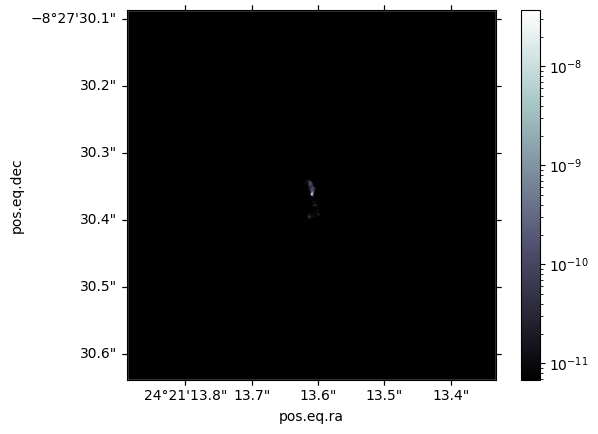

In [66]:
# Constant sky center from lens map
galaxy_coord = SkyCoord(24.35378054, -8.45843384,unit="deg")

g = Galaxy("output.txt", galaxy_coord, z, 1000)
star_fig, star_ax = g.plot(800, filter_name=filter)
star_fig.show()

In [67]:
gas_x = ang_size(ad["gas", "x"].to("pc") - center_code[0].to("pc"), z).value
gas_y = ang_size(ad["gas", "y"].to("pc") - center_code[1].to("pc"), z).value
gas_x.shape, gas_y.shape, ad["gas", "total_flux_" + filter].shape

((12345208,), (12345208,), (12345208,))

In [68]:
gas_x

array([-516.69320334, -516.69320334, -516.69320334, ..., -266.15465129,
       -266.15465129, -266.15465129])

In [69]:
pixel_scale = g.pixel_scale(800)
pivot_wav = pivot_wavelength(filter, z)
flux = 7.5e10 * (pivot_wav / 1500.0) ** 2 * ad["gas", "total_flux_" + filter].value
angular_size = ang_size(200, z)
np.unique(flux)

array([8.14535360e-32, 8.14936178e-32, 8.23028787e-32, ...,
       1.42835937e-07, 1.54918467e-07, 1.66463888e-07])

In [92]:
gas_flux, _, _ = np.histogram2d(
            gas_x,
            gas_y,
            bins=800,
            weights=flux,
            range=[
                [-angular_size, angular_size],
                [-angular_size, angular_size],
            ],
        )
gas_flux.shape, np.unique(gas_flux)

((800, 800),
 array([0.00000000e+00, 1.61210214e-23, 7.56339606e-21, ...,
        7.46032965e-06, 8.10003783e-06, 9.38628516e-06]))

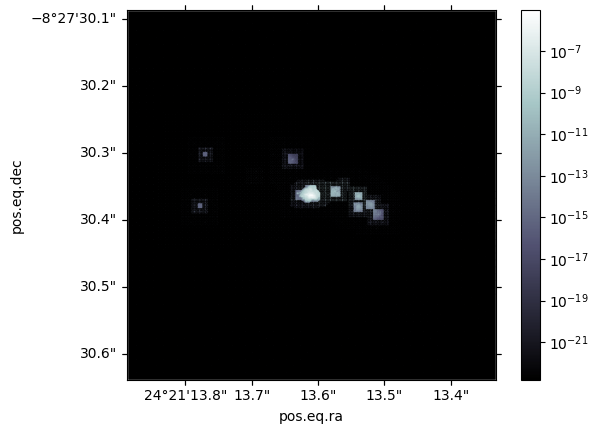

In [93]:
# code from silmaril plot galaxy
wcs = g.grid(800).wcs
fig = plt.figure()
ax = fig.add_subplot(projection=wcs)
im = ax.imshow(gas_flux, cmap="bone", norm=LogNorm())
ax.set_facecolor("black")
ra = ax.coords["ra"]
ra.set_ticklabel(exclude_overlapping=True)
ra.set_format_unit("deg")
# ax.coords.grid(color='white', alpha=0.5, linestyle='solid')
fig.colorbar(im)

yt : [INFO     ] 2026-05-04 17:05:02,239 Identified   162/  384 intersecting domains (  385 through hilbert key indexing)
c:\Users\kevin\AppData\Local\Programs\Python\Python311\Lib\site-packages\yt\frontends\ramses\fields.py:241: RuntimeWarning: Trying to calculate temperature but the cooling tables couldn't be found or read. yt will return T/µ instead of T — this is equivalent to assuming µ=1.0. To suppress this, derive the temperature from temperature_over_mu with some values for mu.
  warnings.warn(
yt : [INFO     ] 2026-05-04 17:06:17,793 Projection completed
yt : [INFO     ] 2026-05-04 17:06:17,802 xlim = 0.491068 0.491274
yt : [INFO     ] 2026-05-04 17:06:17,803 ylim = 0.492673 0.492879
yt : [INFO     ] 2026-05-04 17:06:17,807 xlim = 0.491068 0.491274
yt : [INFO     ] 2026-05-04 17:06:17,809 ylim = 0.492673 0.492879
yt : [INFO     ] 2026-05-04 17:06:17,817 Making a fixed resolution buffer of (('gas', 'total_flux_F200W')) 800 by 800


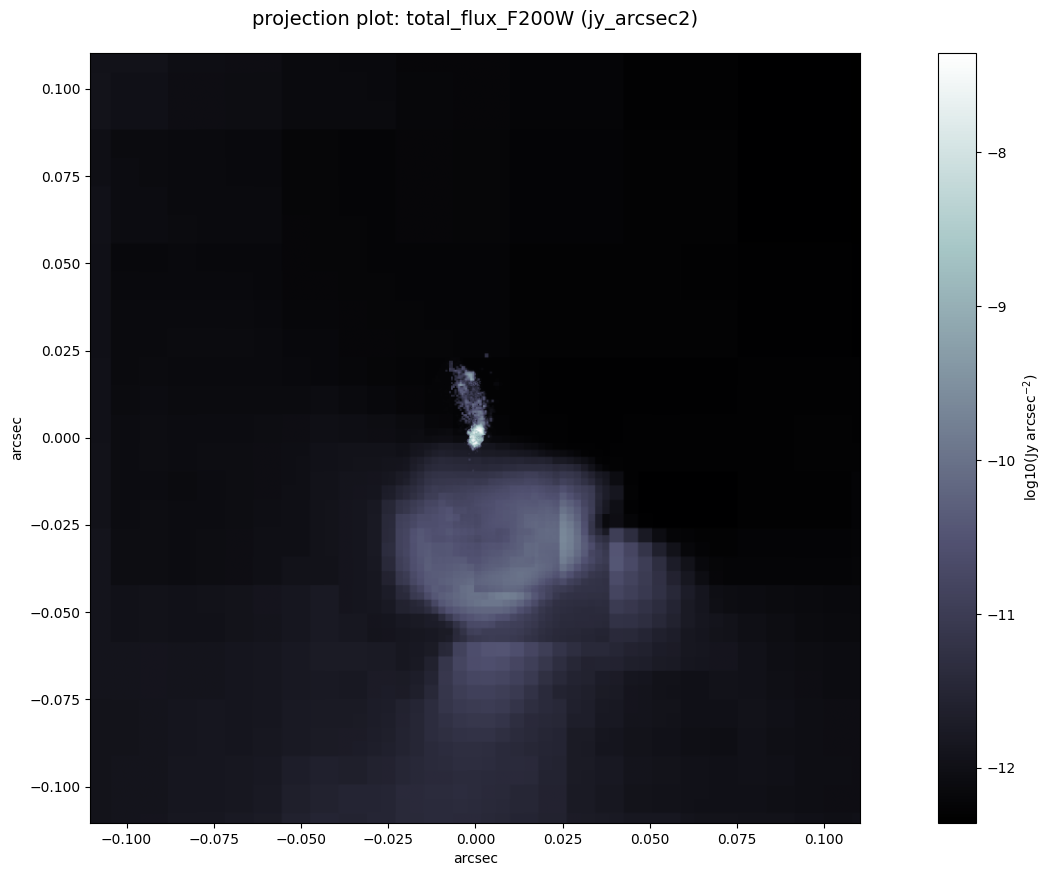

In [98]:
gas_flux = create_projection_plot(
    ds = ds,
    field_name =("total_flux_" + filter),
    ctr_at_code = center_code,
    plt_wdth=800,
    plot_units = "jy_arcsec2",
    z = ds.current_redshift,
    distance_pc = distance_pc,
    axis_units="arcsec",
    filter_path=filter_file
)

In [99]:
gas_flux = 10 ** gas_flux
gas_flux

array([[1.21080706e-12, 1.21080706e-12, 1.21080706e-12, ...,
        1.03739626e-12, 1.03739626e-12, 1.03739626e-12],
       [1.21080706e-12, 1.21080706e-12, 1.21080706e-12, ...,
        1.03739626e-12, 1.03739626e-12, 1.03739626e-12],
       [1.21080706e-12, 1.21080706e-12, 1.21080706e-12, ...,
        1.03739626e-12, 1.03739626e-12, 1.03739626e-12],
       ...,
       [1.15914974e-12, 1.15914974e-12, 1.15914974e-12, ...,
        4.39934487e-13, 4.39934487e-13, 4.39934487e-13],
       [1.15914974e-12, 1.15914974e-12, 1.15914974e-12, ...,
        4.39934487e-13, 4.39934487e-13, 4.39934487e-13],
       [1.15914974e-12, 1.15914974e-12, 1.15914974e-12, ...,
        4.39934487e-13, 4.39934487e-13, 4.39934487e-13]])

In [100]:
stars_image = g.create_image(800, filter_name=filter)
np.unique(stars_image)

array([0.00000000e+00, 6.87593797e-12, 6.92965770e-12, 6.93527993e-12,
       6.95459726e-12, 6.95635974e-12, 6.97282298e-12, 6.97448847e-12,
       6.97547582e-12, 6.97617601e-12, 6.97657615e-12, 6.97917289e-12,
       6.98233409e-12, 6.98512085e-12, 6.98866664e-12, 6.99050485e-12,
       6.99128036e-12, 7.04181871e-12, 7.12758495e-12, 7.21495032e-12,
       7.23245163e-12, 7.43919873e-12, 7.44021863e-12, 7.45397925e-12,
       7.46809206e-12, 7.47045082e-12, 7.70261710e-12, 7.71337370e-12,
       7.78934921e-12, 8.01666113e-12, 8.05151604e-12, 8.05623967e-12,
       8.08739772e-12, 8.09150464e-12, 8.10565857e-12, 8.10802397e-12,
       8.15605818e-12, 8.22701221e-12, 8.28670461e-12, 8.28765952e-12,
       8.28807846e-12, 1.09627159e-11, 1.10234309e-11, 1.10276081e-11,
       1.13099038e-11, 1.13302222e-11, 1.17632790e-11, 1.17737336e-11,
       1.17741859e-11, 1.17834485e-11, 1.17837546e-11, 1.17872357e-11,
       1.19156348e-11, 1.37518759e-11, 1.38112179e-11, 1.38705599e-11,
      

[4.39934487e-13 4.39934487e-13 4.39934487e-13 ... 3.92606197e-08
 4.45351472e-08 4.47800563e-08]


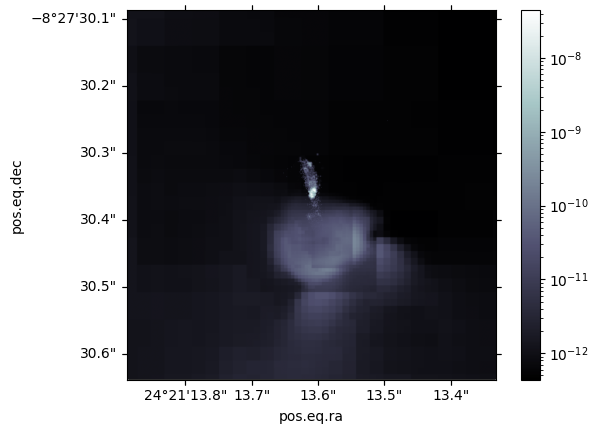

In [101]:
total_image = stars_image + gas_flux
print(np.unique(total_image))
# code from silmaril plot galaxy
wcs = g.grid(800).wcs
fig = plt.figure()
ax = fig.add_subplot(projection=wcs)
im = ax.imshow(total_image, cmap="bone", norm=LogNorm())
ax.set_facecolor("black")
ra = ax.coords["ra"]
ra.set_ticklabel(exclude_overlapping=True)
ra.set_format_unit("deg")
# ax.coords.grid(color='white', alpha=0.5, linestyle='solid')
fig.colorbar(im)


In [96]:
x_deflections = open_fits(r"./silmaril_playground/hlsp_relics_model_model_whl0137m08_glafic_v1_x-arcsec-deflect.fits")
y_deflections = open_fits(r"./silmaril_playground/hlsp_relics_model_model_whl0137m08_glafic_v1_y-arcsec-deflect.fits")

# fits file is the standard for astronomy community for 
wcs = astropy.wcs.WCS(astropy.io.fits.open(r"./silmaril_playground/hlsp_relics_model_model_whl0137m08_glafic_v1_x-arcsec-deflect.fits")[0].header)
lens = Lens(x_deflections,y_deflections,wcs,redshift=0.566,unit='arcsec')

#Line below is characterized by the "detector"
detector_coord = SkyCoord(24.3468342,-8.4645026,unit="deg")
detector = Detector(resolution=0.031,fov=30,center=detector_coord,psf_fwhm=2.065)

observation = Observation(detector,lens,g)

[0. 0. 0. ... 0. 0. 0.]
[0.00000000e+00 4.74147689e-25 1.79790454e-22 ... 7.77574339e-07
 8.46080593e-07 9.79982486e-07]


(<Figure size 640x480 with 2 Axes>, <WCSAxes: >)

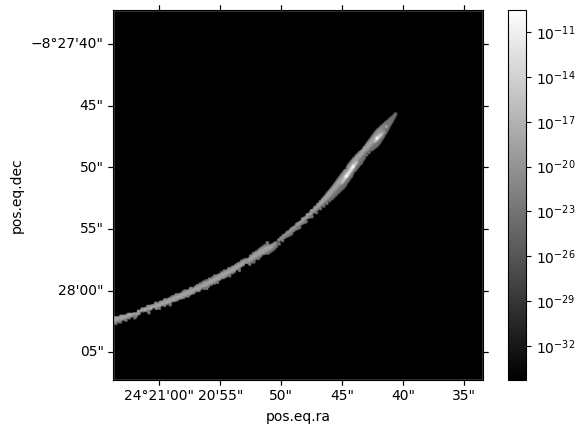

In [97]:
observation.plot(background=0,noise=0,source_resolution=800,star_by_star=False,filter_name=filter, src_image=total_image)